In [16]:
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


In [3]:
train_data = pd.read_csv('/Users/kanishkkaul/Desktop/DATA603 Project 1/TrainingData.csv')
test_data = pd.read_csv('/Users/kanishkkaul/Desktop/DATA603 Project 1/TestingData.csv')


In [4]:
train_data.head()

,Age,Annual Income,Credit Score,Experience,Loan Amount,Loan Duration,Number of Dependents,Monthly Debt Payment,Creditcard Utilizatio Rate,Number of Open Credit Lines,...,Total Assets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,146111,19183,3329.000000,0.724972,11,126928,0.227590,419.805992,0.181077,0
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,53204,9595,3309.083333,0.935132,3,43609,0.201077,794.054238,0.389852,0
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,25176,128874,3393.666667,0.872241,6,5205,0.212548,666.406688,0.462157,0
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,104822,5370,5757.000000,0.896155,5,99452,0.300911,1047.506980,0.313098,0
4,58,51250,564,39,12741,48,0,337,0.367380,6,...,65624,43894,4270.833333,0.884275,5,21730,0.205271,391.300352,0.170529,0


In [5]:
test_data.head()

,Age,Annual Income,Credit Score,Experience,Loan Amount,Loan Duration,Number of Dependents,Monthly Debt Payment,Creditcard Utilizatio Rate,Number of Open Credit Lines,...,Total Assets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,53,42478,552,33,10463,72,2,597,0.383507,5,...,27296,30757,3539.833333,0.972212,7,5996,0.221873,264.059369,0.243249,0
1,54,25911,571,28,10751,60,4,544,0.321581,2,...,15047,65767,2159.250000,0.841848,5,5576,0.244892,312.344769,0.396594,0
2,18,27112,432,0,32743,72,0,821,0.531712,1,...,48699,8253,2259.333333,0.794940,4,40446,0.378836,1157.134465,0.875539,0
3,35,54015,612,14,13313,60,3,298,0.196421,1,...,80818,3399,4501.250000,0.754604,4,77419,0.202899,354.864257,0.145041,0
4,35,32033,585,10,24194,12,2,302,0.448020,4,...,127782,80487,2669.416667,0.910957,5,47295,0.225888,2271.284384,0.963988,0


In [6]:
# Separate features and labels
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

In [7]:
# Function to calculate Type 1 and Type 2 errors
def calculate_type_errors(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    type_1_error = float(fp / (fp + tn))  # False positive rate
    type_2_error = float(fn / (fn + tp))  # False negative rate
    return type_1_error, type_2_error

# Part 1: Results with Original Features
results = {}

In [8]:
# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
results['LDA (Original)'] = {
    'Accuracy': float(accuracy_score(y_test, y_pred_lda)),
    'Type 1 Error': calculate_type_errors(y_test, y_pred_lda)[0],
    'Type 2 Error': calculate_type_errors(y_test, y_pred_lda)[1]
}
print(f"LDA (Original): Accuracy={results['LDA (Original)']['Accuracy']}, "
      f"Type 1 Error={results['LDA (Original)']['Type 1 Error']}, "
      f"Type 2 Error={results['LDA (Original)']['Type 2 Error']}")

LDA (Original): Accuracy=0.905, Type 1 Error=0.16, Type 2 Error=0.03


In [9]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
results['Decision Tree (Original)'] = {
    'Accuracy': float(accuracy_score(y_test, y_pred_dt)),
    'Type 1 Error': calculate_type_errors(y_test, y_pred_dt)[0],
    'Type 2 Error': calculate_type_errors(y_test, y_pred_dt)[1]
}
print(f"Decision Tree (Original): Accuracy={results['Decision Tree (Original)']['Accuracy']}, "
      f"Type 1 Error={results['Decision Tree (Original)']['Type 1 Error']}, "
      f"Type 2 Error={results['Decision Tree (Original)']['Type 2 Error']}")


Decision Tree (Original): Accuracy=0.82, Type 1 Error=0.155, Type 2 Error=0.205


In [10]:
# kNN with different k-values (1, 3, 5, 10)
k_values = [1, 3, 5, 10]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    results[f'kNN (k={k}) (Original)'] = {
        'Accuracy': float(accuracy_score(y_test, y_pred_knn)),
        'Type 1 Error': calculate_type_errors(y_test, y_pred_knn)[0],
        'Type 2 Error': calculate_type_errors(y_test, y_pred_knn)[1]
    }
    print(f"kNN (k={k}) (Original): Accuracy={results[f'kNN (k={k}) (Original)']['Accuracy']}, "
          f"Type 1 Error={results[f'kNN (k={k}) (Original)']['Type 1 Error']}, "
          f"Type 2 Error={results[f'kNN (k={k}) (Original)']['Type 2 Error']}")


kNN (k=1) (Original): Accuracy=0.7825, Type 1 Error=0.25, Type 2 Error=0.185
kNN (k=3) (Original): Accuracy=0.8225, Type 1 Error=0.185, Type 2 Error=0.17
kNN (k=5) (Original): Accuracy=0.8325, Type 1 Error=0.2, Type 2 Error=0.135
kNN (k=10) (Original): Accuracy=0.8325, Type 1 Error=0.17, Type 2 Error=0.165


In [11]:
# SVM
svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
results['SVM (Original)'] = {
    'Accuracy': float(accuracy_score(y_test, y_pred_svm)),
    'Type 1 Error': calculate_type_errors(y_test, y_pred_svm)[0],
    'Type 2 Error': calculate_type_errors(y_test, y_pred_svm)[1]
}
print(f"SVM (Original): Accuracy={results['SVM (Original)']['Accuracy']}, "
      f"Type 1 Error={results['SVM (Original)']['Type 1 Error']}, "
      f"Type 2 Error={results['SVM (Original)']['Type 2 Error']}")

SVM (Original): Accuracy=0.875, Type 1 Error=0.18, Type 2 Error=0.07


Comparison of Model Performance:
                          Accuracy  Type 1 Error  Type 2 Error
LDA (Original)              0.9050         0.160         0.030
Decision Tree (Original)    0.8200         0.155         0.205
kNN (k=1) (Original)        0.7825         0.250         0.185
kNN (k=3) (Original)        0.8225         0.185         0.170
kNN (k=5) (Original)        0.8325         0.200         0.135
kNN (k=10) (Original)       0.8325         0.170         0.165
SVM (Original)              0.8750         0.180         0.070


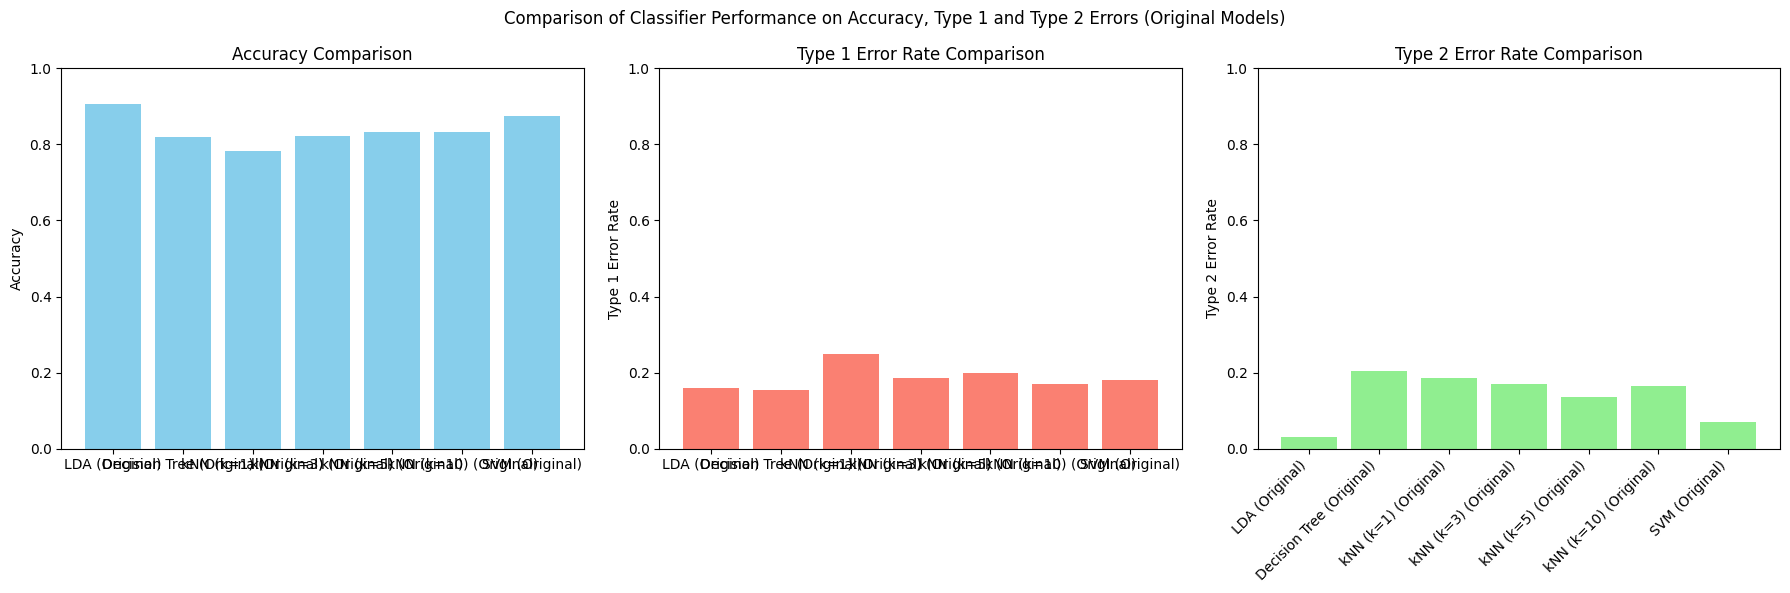

In [12]:
# Convert results dictionary to DataFrame for easy visualization
results_df = pd.DataFrame(results).T
print("Comparison of Model Performance:")
print(results_df)

# Plot comparison for accuracy, Type 1, and Type 2 error rates (Original Models Only)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy Comparison
axs[0].bar(results_df.index, results_df['Accuracy'], color='skyblue')
axs[0].set_title('Accuracy Comparison')
axs[0].set_ylabel('Accuracy')
axs[0].set_ylim([0, 1])

# Type 1 Error Comparison
axs[1].bar(results_df.index, results_df['Type 1 Error'], color='salmon')
axs[1].set_title('Type 1 Error Rate Comparison')
axs[1].set_ylabel('Type 1 Error Rate')
axs[1].set_ylim([0, 1])

# Type 2 Error Comparison
axs[2].bar(results_df.index, results_df['Type 2 Error'], color='lightgreen')
axs[2].set_title('Type 2 Error Rate Comparison')
axs[2].set_ylabel('Type 2 Error Rate')
axs[2].set_ylim([0, 1])

plt.suptitle("Comparison of Classifier Performance on Accuracy, Type 1 and Type 2 Errors (Original Models)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [13]:
# Part 2: Results with PCA-Reduced Features
pca_results = {}
pca_components = [5, 10, 15]

for n_components in pca_components:
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # kNN with PCA-reduced features
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_pca, y_train)
    y_pred_knn_pca = knn.predict(X_test_pca)
    pca_results[f'kNN (PCA={n_components})'] = {
        'Accuracy': float(accuracy_score(y_test, y_pred_knn_pca)),
        'Type 1 Error': calculate_type_errors(y_test, y_pred_knn_pca)[0],
        'Type 2 Error': calculate_type_errors(y_test, y_pred_knn_pca)[1]
    }
    print(f"kNN (PCA={n_components}): Accuracy={pca_results[f'kNN (PCA={n_components})']['Accuracy']}, "
          f"Type 1 Error={pca_results[f'kNN (PCA={n_components})']['Type 1 Error']}, "
          f"Type 2 Error={pca_results[f'kNN (PCA={n_components})']['Type 2 Error']}")

    # SVM with PCA-reduced features
    svm = SVC(kernel='linear', C=1.0)
    svm.fit(X_train_pca, y_train)
    y_pred_svm_pca = svm.predict(X_test_pca)
    pca_results[f'SVM (PCA={n_components})'] = {
        'Accuracy': float(accuracy_score(y_test, y_pred_svm_pca)),
        'Type 1 Error': calculate_type_errors(y_test, y_pred_svm_pca)[0],
        'Type 2 Error': calculate_type_errors(y_test, y_pred_svm_pca)[1]
    }
    print(f"SVM (PCA={n_components}): Accuracy={pca_results[f'SVM (PCA={n_components})']['Accuracy']}, "
          f"Type 1 Error={pca_results[f'SVM (PCA={n_components})']['Type 1 Error']}, "
          f"Type 2 Error={pca_results[f'SVM (PCA={n_components})']['Type 2 Error']}")


kNN (PCA=5): Accuracy=0.8425, Type 1 Error=0.19, Type 2 Error=0.125
SVM (PCA=5): Accuracy=0.865, Type 1 Error=0.19, Type 2 Error=0.08
kNN (PCA=10): Accuracy=0.8325, Type 1 Error=0.2, Type 2 Error=0.135
SVM (PCA=10): Accuracy=0.8725, Type 1 Error=0.175, Type 2 Error=0.08
kNN (PCA=15): Accuracy=0.8325, Type 1 Error=0.2, Type 2 Error=0.135
SVM (PCA=15): Accuracy=0.885, Type 1 Error=0.165, Type 2 Error=0.065


In [14]:
# Convert dictionaries to DataFrames for comparison
results_df = pd.DataFrame(results).T
pca_results_df = pd.DataFrame(pca_results).T

# Extract data for plotting
accuracy_original = {model: data['Accuracy'] for model, data in results.items()}
accuracy_pca = {model: data['Accuracy'] for model, data in pca_results.items()}

type1_error_original = {model: data['Type 1 Error'] for model, data in results.items()}
type1_error_pca = {model: data['Type 1 Error'] for model, data in pca_results.items()}

type2_error_original = {model: data['Type 2 Error'] for model, data in results.items()}
type2_error_pca = {model: data['Type 2 Error'] for model, data in pca_results.items()}

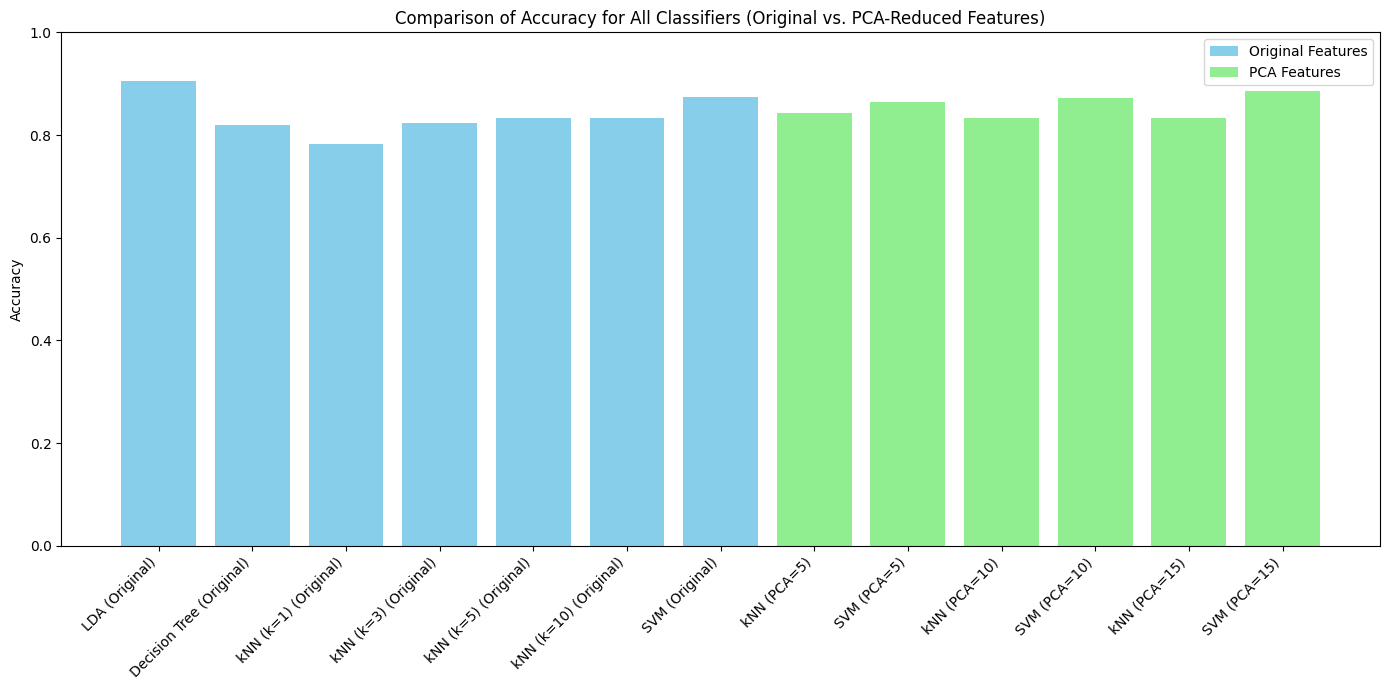

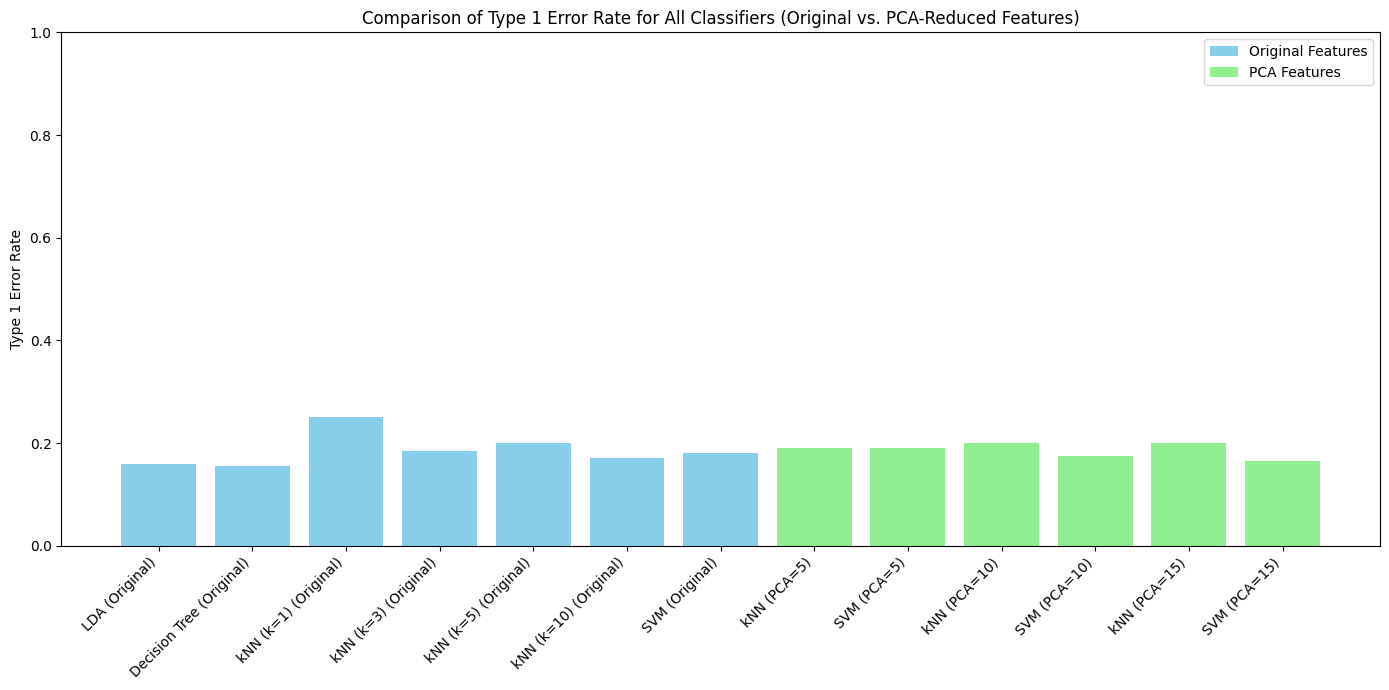

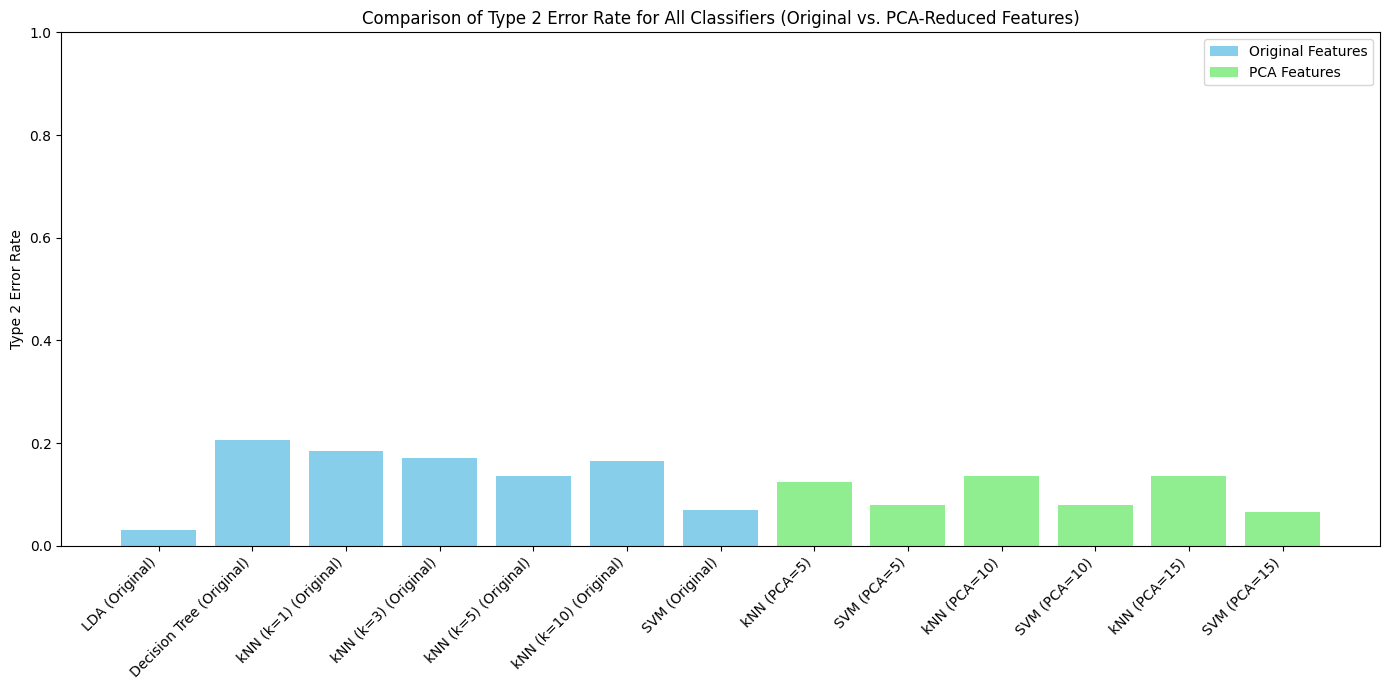

In [15]:
# Plotting function
def plot_comparison(metric_data_original, metric_data_pca, metric_name):
    plt.figure(figsize=(14, 7))

    model_names = list(metric_data_original.keys()) + list(metric_data_pca.keys())
    
    # Plot original and PCA-based metrics
    plt.bar(np.arange(len(metric_data_original)), list(metric_data_original.values()), color="skyblue", label="Original Features")
    plt.bar(np.arange(len(metric_data_original), len(model_names)), list(metric_data_pca.values()), color="lightgreen", label="PCA Features")
    
    # Customize x-ticks and labels
    plt.xticks(ticks=np.arange(len(model_names)), labels=model_names, rotation=45, ha="right")
    plt.ylabel(metric_name)
    plt.title(f"Comparison of {metric_name} for All Classifiers (Original vs. PCA-Reduced Features)")
    plt.ylim([0, 1])
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    
# Plotting accuracy, type 1 error, and type 2 error
plot_comparison(accuracy_original, accuracy_pca, "Accuracy")
plot_comparison(type1_error_original, type1_error_pca, "Type 1 Error Rate")
plot_comparison(type2_error_original, type2_error_pca, "Type 2 Error Rate")